# Valitation of null hypothesis from stocks returns

In this notebook, we evaluate several null hypotheses related to stock returns and their statistical properties for the selected asset.

- First, we test whether the variance of arithmetic returns and log returns is the same using Levene’s test.
- Second, we test whether the mean difference between arithmetic and log returns is statistically significant (using a paired-test framework).
- Third, we fit candidate probability distributions to both return series and compare their goodness of fit to assess whether the normality assumption is appropriate.

These steps help us validate key assumptions commonly used in return modeling and financial analysis.

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import yfinance as yf

from dotenv import load_dotenv
import os
import sys

In [5]:
pd.options.display.float_format = '{:,.2f}'.format

In [8]:
load_dotenv()  # carga .env
sys.path.insert(0, os.path.join(os.environ["CUANTIS_ROOT"], "src"))

In [16]:
# CVX
tickets = ["CVX"]

start_date = "2016-02-11"
end_date = "2026-02-11"

In [17]:
prices = yf.download(tickets, start_date, end_date)["Close"]

[*********************100%***********************]  1 of 1 completed


In [30]:
prices["CVX_ln"] = np.log(prices["CVX"])
prices.head(3)

Ticker,CVX,CVX_ln
Date,,
2016-02-11,54.10,3.99
2016-02-12,55.69,4.02
2016-02-16,55.99,4.03


In [22]:
returns = pd.DataFrame()

In [34]:
returns["R"] = prices["CVX"].pct_change().dropna()

returns["r"] = prices["CVX_ln"] - prices["CVX_ln"].shift(1)

returns.head(5)

,R,r
Date,,
2016-02-12,0.03,0.03
2016-02-16,0.01,0.01
2016-02-17,0.04,0.04
2016-02-18,-0.02,-0.02
2016-02-19,-0.00,-0.00


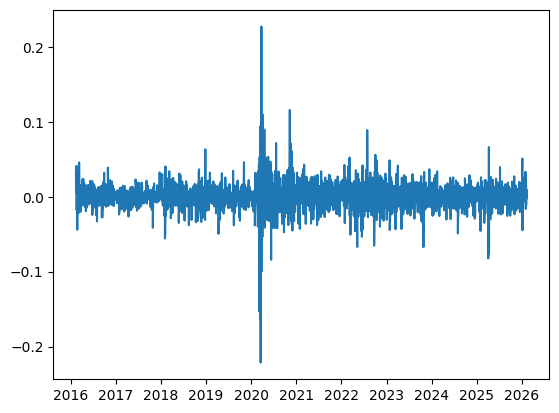

In [37]:
plt.plot(returns["R"])

plt.show()

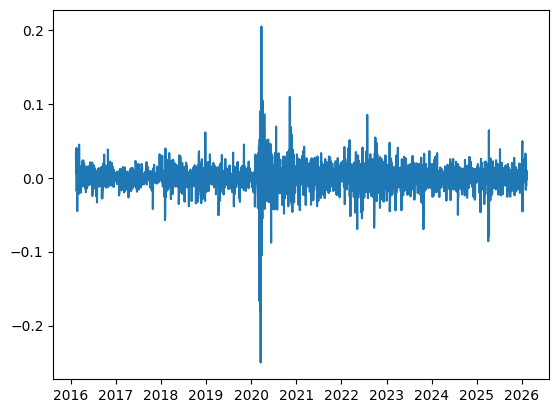

In [38]:
plt.plot(returns["r"])

plt.show()

## Test 1: Variances test

In [40]:
alpha = 0.05

w, p_value = stats.levene(returns["R"], returns["r"])

if p_value < alpha:
    print("Varianzas diferentes")
else:
    print("Varianzas iguales")

Varianzas iguales


## Test 2: Mean test

In [68]:
w, p_value = stats.ttest_ind(returns["R"]-returns["r"], 0)

if p_value < alpha:
    print("Medias diferentes")
else:
    print("Medias iguales")

Medias iguales


since the test is failed, we need test if the following relations is hold

$$
R_t - \frac{\sigma^2}{2} = r_t
$$

whether the above ecuation is true. Then it implice that

$$
R_t \neq r_t
$$

So, we continue with our stock model

In [65]:
r_t = returns["R"] - ((returns["R"]**2)/2)

In [67]:
w, p_value = stats.ttest_ind(r_t, returns["R"])

if p_value < 0.05:
    print("Medias diferentes")
else:
    print("Medias iguales")

Medias iguales


So, we could said that both means are equal and we continue with our process

## Test 3: ML test over data

In [ ]:
from cuantis_utils.TestDistribuitions import best_fit_distribution

In [56]:
name_best_distribution_R, best_params_dist_R = best_fit_distribution(returns["R"])
name_best_distribution_R

'nct'

In [57]:
name_best_distribution_r, best_params_dist_r = best_fit_distribution(returns["r"])
name_best_distribution_r

'nct'

### PDF

In [ ]:
from cuantis_utils.TestDistribuitions import make_pdf

In [58]:
best_dist_R = getattr(stats, name_best_distribution_R)
best_dist_r = getattr(stats, name_best_distribution_r)

In [61]:
pdf_R = make_pdf(best_dist_R, best_params_dist_R, size = 4000)
pdf_r = make_pdf(best_dist_r, best_params_dist_r, size = 4000)

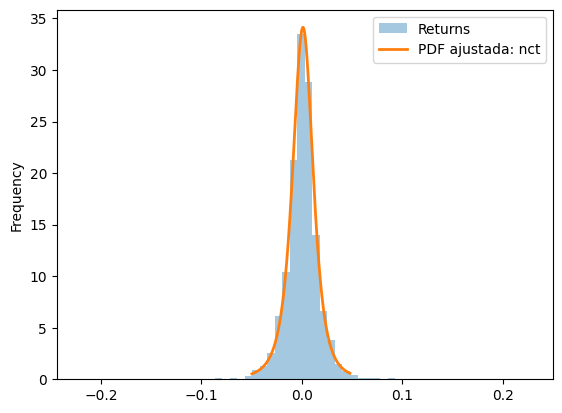

In [62]:
ax = pd.Series(returns["R"]).plot(kind="hist", bins=60, density=True, alpha=0.4, label="Returns")
pdf_R.plot(ax=ax, lw=2, label=f"PDF ajustada: {name_best_distribution_R}")
ax.legend()
plt.show()

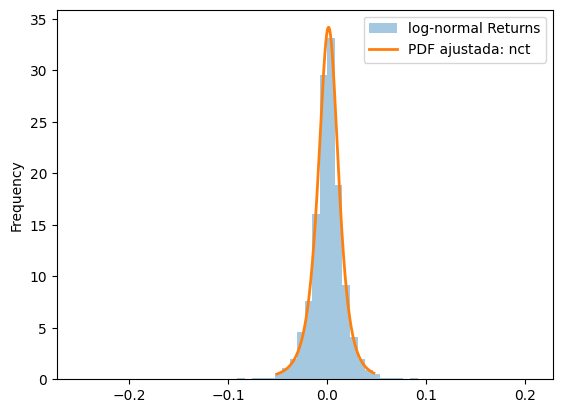

In [63]:
ax = pd.Series(returns["r"]).plot(kind="hist", bins=60, density=True, alpha=0.4, label="log-normal Returns")
pdf_r.plot(ax=ax, lw=2, label=f"PDF ajustada: {name_best_distribution_r}")
ax.legend()
plt.show()

## Conclutions

The results show that both arithmetic and logarithmic returns are better fitted by an nct (non-central t) distribution than by a normal distribution. Although the tests were applied correctly and produced favorable results in terms of the statistical procedure, this suggests that, for the selected asset, log returns do not fully satisfy the normality assumption. Even so, the nct distribution is related to the normal family and can be interpreted as an extension that better captures these deviations.
